<a href="https://colab.research.google.com/github/carlos31255/EV2_ML/blob/main/notebooks/EV2_Spotify_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV2 — Machine Learning 
## Caso C: Predicción de popularidad de canciones en Spotify — Modelamiento

**Estrategia:** clasificación binaria **hit / no-hit** (popularidad ≥ P80 del conjunto de entrenamiento).

### Qué se corrige respecto de la versión anterior de EV2

| # | Problema en la versión anterior | Corrección en este notebook |
|---|---|---|
| 1 | Se conservaban las filas repetidas por `track_id` (una por género): una canción en 4 géneros pesaba 4 veces en el entrenamiento (observación del docente en EP1). | **Una fila por canción** (`track_id`); los géneros pasan a columnas multi-hot. |
| 2 | El `train_test_split` separaba por fila: la misma canción quedaba en train y en test (**fuga de datos**), también dentro de la validación cruzada. | Split y CV **por grupos de canción** (`GroupShuffleSplit`, `StratifiedGroupKFold`). |
| 3 | `track_genre_encoded` (Label Encoding 0-113) mantenía un orden alfabético falso; no escalarlo no lo elimina. | **One-hot** para `key` y `time_signature`, **multi-hot** para género. |
| 4 | El umbral P80 se calculaba con todo el dataset antes del split. | El umbral se calcula **solo con train**. |
| 5 | El StandardScaler se aplicaba fuera de la validación cruzada. | Preprocesamiento dentro de un `Pipeline`: se ajusta **solo con el fold de entrenamiento**. |
| 6 | Gradient Boosting con recall 0.1538 (umbral 0.5 sin balanceo de clases). | `HistGradientBoostingClassifier(class_weight='balanced')`. |

## 0. Comprensión del negocio y metodología (CRISP-DM)

### 0.1 Problema de negocio
Un sello discográfico (o equipo de A&R de una plataforma) debe decidir **en qué canciones invertir** (firma, promoción, playlists)
con un presupuesto limitado y sin saber de antemano cuáles serán populares. La pregunta de negocio es:

> **¿Invierto o no en esta canción?** ¿Qué canciones tienen mayor probabilidad de convertirse en *hit*, y qué tipos de canciones existen en el catálogo?

Se modela como **clasificación binaria** (*hit* = popularidad ≥ P80 del conjunto de entrenamiento) porque la decisión del negocio es binaria y
porque en EP1 se vio que ninguna variable de audio tiene correlación lineal fuerte con `popularity` (una regresión tendría muy poco poder explicativo).

### 0.2 Objetivos del proyecto
1. **Supervisado:** predecir si una canción será *hit* a partir de sus características de audio, metadatos y género.
2. **Comparación:** implementar y comparar al menos dos modelos supervisados (regresión logística, Random Forest y Gradient Boosting), validados **por canción**.
3. **No supervisado:** descubrir **segmentos de canciones** por perfil sonoro (K-Means) y evaluar qué segmentos concentran más o menos *hits*.
4. **Decisión:** traducir las métricas en recomendaciones concretas para el negocio.

### 0.3 KPIs y metas de referencia
| KPI | Definición | Meta de referencia | Por qué importa al negocio |
|---|---|---|---|
| **AUC-ROC** (principal) | Capacidad de ordenar hits por encima de no-hits, independiente del umbral | ≥ 0.80 | Permite **rankear** el catálogo y armar listas de candidatas |
| **Recall de hit** | % de hits reales que el modelo detecta | ≥ 0.75 | Costo de oportunidad: no dejar pasar hits |
| **Lift @ top-10%** | Tasa de hits en el 10% mejor rankeado ÷ tasa base de hits | ≥ 2.0 | Eficiencia de la inversión frente a elegir al azar |
| **Silhouette y estabilidad (ARI)** | Calidad y reproducibilidad de los segmentos | ARI ≥ 0.90 entre semillas | Segmentos confiables para estrategia de catálogo |

*Las metas son valores de referencia definidos por el equipo para evaluar el modelo; el negocio puede ajustarlas.*

### 0.4 Fuentes de datos
**Spotify Tracks Dataset** (Maharshi Pandya; Kaggle, espejo en Hugging Face): 114.000 filas y 21 columnas (audio features, metadatos y `track_genre`).
La descripción completa, el EDA, la calidad de datos y la evaluación ética están en `EV1_Spotify.ipynb` (EP1).

### 0.5 Metodología: CRISP-DM
| Fase CRISP-DM | Dónde se desarrolla |
|---|---|
| 1. Comprensión del negocio | Sección 0 (este notebook) |
| 2. Comprensión de los datos | EP1 (`EV1_Spotify.ipynb`: EDA, calidad, correlaciones, sesgos) + secciones 1 y 2 (diagnóstico de duplicados y fuga de datos) |
| 3. Preparación de los datos | EP1 sección 11 (limpieza, `log1p`) + secciones 3 a 5 (una fila por canción, multi-hot, split por canción, Pipeline) |
| 4. Modelado | Sección 5 y 6 (supervisados con validación cruzada) y sección 9 (no supervisado) |
| 5. Evaluación | Secciones 7 y 8 (métricas, KPIs, diagnóstico de géneros y ablación 7.2 a 7.6, importancia) y sección 10 (resumen) |
| 6. Despliegue | Sección 11 (modelos serializados en `models/`) y sección 12 (recomendaciones de negocio) |

**CRISP-DM es iterativo, y aquí se aplicó así:** la observación del docente sobre EP1 (las canciones en varios géneros pesaban más en el entrenamiento)
obligó a **volver de la Evaluación a la Preparación de datos** y rehacer el proceso (secciones 2 a 4).

In [1]:
import os
import sys
import joblib
# Soporte para ejecucion directa en Google Colab
if 'google.colab' in sys.modules:
    if not os.path.exists('data/processed/spotify_clean.csv'):
        print("[INFO] Detectado entorno Google Colab. Clonando repositorio...")
        import subprocess
        subprocess.run(['git', 'clone', 'https://github.com/carlos31255/EV2_ML.git'], check=True)
        if os.path.exists('EV2_ML'):
            os.chdir('EV2_ML')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import (train_test_split, GroupShuffleSplit,
                                     StratifiedGroupKFold, cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay, f1_score, precision_score,
                             recall_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

SPOTIFY_GREEN = '#1DB954'
BG_COLOR, TEXT_COLOR = '#121212', '#FFFFFF'
matplotlib.rcParams.update({
    'figure.dpi': 100, 'axes.facecolor': '#1a1a1a', 'figure.facecolor': BG_COLOR,
    'text.color': TEXT_COLOR, 'axes.labelcolor': TEXT_COLOR, 'xtick.color': TEXT_COLOR,
    'ytick.color': TEXT_COLOR, 'axes.edgecolor': '#333333', 'grid.color': '#333333',
})
SEED = 42
np.random.seed(SEED)
os.makedirs('images', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('[OK] Librerías cargadas. Working directory:', os.getcwd())

[OK] Librerías cargadas. Working directory: /home/claude/proj


## 1. Carga del dataset limpio (EV1)

In [2]:
df = pd.read_csv('data/processed/spotify_clean.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (113549, 25)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,speechiness_log,instrumentalness_log,liveness_log,duration_ms_log,track_genre_encoded
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,...,0.358,0.715,87.917,4,acoustic,0.133656,0.000001,0.306013,12.348730,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,...,0.101,0.267,77.489,4,acoustic,0.073529,0.000006,0.096219,11.915794,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,...,0.117,0.120,76.332,4,acoustic,0.054204,0.000000,0.110647,12.258793,0


## 2. Diagnóstico: canciones repetidas por género

El dataset se armó por género (~1.000 filas por género). Una canción incluida en varios géneros aparece
como varias filas con el mismo `track_id`. Aquí se mide cuánto pesa eso.

In [3]:
n_filas = len(df)
n_canciones = df['track_id'].nunique()
print(f'Filas totales               : {n_filas:,}')
print(f'Canciones únicas (track_id) : {n_canciones:,}')
print(f'Filas "extra" por repetición: {n_filas - n_canciones:,} ({(n_filas - n_canciones)/n_filas*100:.2f}% de las filas)')

# ¿Las filas repetidas son idénticas salvo el género? (popularity y features de audio)
cols_check = [c for c in df.columns if c not in ('track_genre', 'track_genre_encoded')]
variantes = (df.groupby('track_id')[cols_check].nunique(dropna=False) > 1).any(axis=1)
print(f'\ntrack_id cuyas filas difieren en algo más que el género: {variantes.sum():,}')
pop_var = (df.groupby('track_id')['popularity'].nunique() > 1).sum()
print(f'track_id con popularity distinto entre filas            : {pop_var:,}')
dif = df.groupby('track_id')['popularity'].agg(lambda x: x.max() - x.min())
print(f'Diferencia máxima de popularity dentro de un track_id     : {dif.max()} pts | mediana entre los que difieren: {dif[dif > 0].median():.0f} pt')

Filas totales               : 113,549
Canciones únicas (track_id) : 89,740
Filas "extra" por repetición: 23,809 (20.97% de las filas)



track_id cuyas filas difieren en algo más que el género: 720
track_id con popularity distinto entre filas            : 720


Diferencia máxima de popularity dentro de un track_id     : 44 pts | mediana entre los que difieren: 1 pt


N° de géneros por canción -> cantidad de canciones
track_genre
1    73441
2    11424
3     2955
4     1361
5      431
6      104
7       21
8        2
9        1


,canciones,% canciones,filas,% filas
track_genre,,,,
1,73441,81.84,73441,64.68
2,11424,12.73,22848,20.12
3,2955,3.29,8865,7.81
4,1361,1.52,5444,4.79
5,431,0.48,2155,1.90
6,104,0.12,624,0.55
7,21,0.02,147,0.13
8,2,0.00,16,0.01
9,1,0.00,9,0.01


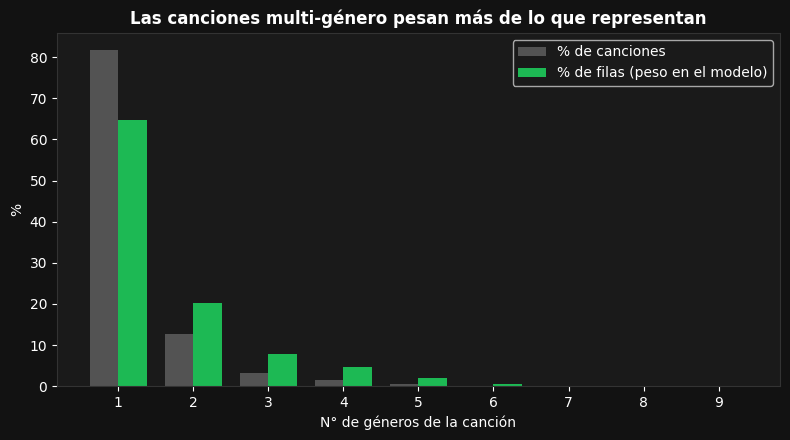

In [4]:
gen_por_cancion = df.groupby('track_id')['track_genre'].nunique()
dist = gen_por_cancion.value_counts().sort_index()
print('N° de géneros por canción -> cantidad de canciones')
print(dist.to_string())

# Peso en el entrenamiento: % de canciones vs % de filas según nº de géneros
filas_por_grupo = dist * dist.index
tabla = pd.DataFrame({
    'canciones': dist,
    '% canciones': (dist / dist.sum() * 100).round(2),
    'filas': filas_por_grupo,
    '% filas': (filas_por_grupo / filas_por_grupo.sum() * 100).round(2),
})
display(tabla)

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=BG_COLOR)
x = np.arange(len(tabla)); w = 0.38
ax.bar(x - w/2, tabla['% canciones'], w, color='#535353', label='% de canciones')
ax.bar(x + w/2, tabla['% filas'], w, color=SPOTIFY_GREEN, label='% de filas (peso en el modelo)')
ax.set_xticks(x); ax.set_xticklabels(tabla.index)
ax.set_xlabel('N° de géneros de la canción'); ax.set_ylabel('%')
ax.set_title('Las canciones multi-género pesan más de lo que representan', fontweight='bold')
ax.legend(facecolor='#1a1a1a', labelcolor=TEXT_COLOR)
plt.tight_layout()
plt.savefig('images/peso_canciones_multigenero.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 2.1 Cuantificación de la fuga de datos (comportamiento de la versión anterior)

Se repite **exactamente** el enfoque anterior (mismas variables, Label Encoding del género, umbral 54,
Random Forest) y se cambia **una sola cosa**: cómo se separa train/test.

- **A)** split aleatorio por fila (como en la versión anterior).
- **B)** split por canción (todas las filas de una misma canción quedan en el mismo lado).

La diferencia de AUC es el efecto de la fuga.

In [5]:
df['song_key'] = (df['artists'].str.lower().str.strip() + '||' + df['track_name'].str.lower().str.strip())

FEATS_DEMO = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'acousticness',
              'speechiness_log', 'instrumentalness_log', 'liveness_log', 'duration_ms_log',
              'explicit', 'mode', 'key', 'time_signature', 'track_genre_encoded']
y_demo = (df['popularity'] >= 54).astype(int)   # umbral fijo de la versión anterior, solo para esta comparación

def rf_demo():
    return RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=10,
                                  class_weight='balanced', random_state=SEED, n_jobs=-1)

# A) split por fila
tr_a, te_a = train_test_split(df.index, test_size=0.20, random_state=SEED, stratify=y_demo)
m = rf_demo().fit(df.loc[tr_a, FEATS_DEMO], y_demo[tr_a])
auc_a = roc_auc_score(y_demo[te_a], m.predict_proba(df.loc[te_a, FEATS_DEMO])[:, 1])
comparte = df.loc[te_a, 'track_id'].isin(df.loc[tr_a, 'track_id']).mean() * 100

# B) split por canción
tr_b, te_b = next(GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
                  .split(df, y_demo, groups=df['song_key']))
m = rf_demo().fit(df.iloc[tr_b][FEATS_DEMO], y_demo.iloc[tr_b])
auc_b = roc_auc_score(y_demo.iloc[te_b], m.predict_proba(df.iloc[te_b][FEATS_DEMO])[:, 1])

print(f'A) Split por fila     -> AUC test = {auc_a:.4f} | filas de test cuya canción ya estaba en train: {comparte:.1f}%')
print(f'B) Split por canción  -> AUC test = {auc_b:.4f}')
print(f'Inflación por fuga de datos: {auc_a - auc_b:+.4f} de AUC')

A) Split por fila     -> AUC test = 0.7958 | filas de test cuya canción ya estaba en train: 30.8%
B) Split por canción  -> AUC test = 0.7505
Inflación por fuga de datos: +0.0453 de AUC


## 3. Una fila por canción + género multi-hot

- Se conserva **una fila por `track_id`**. Las filas repetidas son idénticas salvo el género y, en una minoría de canciones (ver sección 2), el `popularity`, que difiere levemente entre géneros: en esos casos se usa el **promedio** redondeado.
- Los géneros de cada canción se guardan como columnas 0/1 (`genre_<nombre>`): la información de género
  no se pierde, pero la canción ya no se cuenta varias veces.
- Se crea `song_key` (artista + nombre de pista) para agrupar: una misma canción puede tener **distintos**
  `track_id` (versiones en distintos álbumes) y no debe quedar repartida entre train y test.

In [6]:
generos = df.groupby('track_id')['track_genre'].apply(lambda s: sorted(set(s)))

pop_media = df.groupby('track_id')['popularity'].mean().round().astype(int)
df_song = df.drop_duplicates(subset='track_id').set_index('track_id').drop(
    columns=['track_genre', 'track_genre_encoded'])
df_song['popularity'] = pop_media.loc[df_song.index]   # promedio entre géneros (solo cambia en una minoría de canciones)
mlb = MultiLabelBinarizer()
G = pd.DataFrame(mlb.fit_transform(generos.loc[df_song.index]),
                 columns=[f'genre_{g}' for g in mlb.classes_], index=df_song.index)
df_song = pd.concat([df_song, G], axis=1)
df_song['explicit'] = df_song['explicit'].astype(int)

print(f'Filas antes : {len(df):,}')
print(f'Filas ahora : {len(df_song):,} (una por track_id)')
print(f'Columnas de género (multi-hot): {G.shape[1]}')

# Misma canción con distinto track_id (versiones en otros álbumes)
rep = df_song.duplicated('song_key', keep=False).sum()
print(f'\nFilas que comparten song_key con otro track_id: {rep:,} -> se agrupan al separar train/test')

Filas antes : 113,549
Filas ahora : 89,740 (una por track_id)
Columnas de género (multi-hot): 114

Filas que comparten song_key con otro track_id: 13,281 -> se agrupan al separar train/test


## 4. Separación train / test por canción y variable objetivo

El umbral P80 se calcula **solo con el conjunto de entrenamiento** para que el test no influya en la definición de `hit`.

In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_idx, te_idx = next(gss.split(df_song, groups=df_song['song_key']))
train, test = df_song.iloc[tr_idx].copy(), df_song.iloc[te_idx].copy()

P80 = train['popularity'].quantile(0.80)
train['hit'] = (train['popularity'] >= P80).astype(int)
test['hit']  = (test['popularity']  >= P80).astype(int)

print(f'Umbral P80 (solo train): {P80} pts')
print(f'Train: {len(train):,} canciones | hits: {train["hit"].mean()*100:.1f}%')
print(f'Test : {len(test):,} canciones | hits: {test["hit"].mean()*100:.1f}%')
assert set(train['song_key']).isdisjoint(set(test['song_key'])), 'Hay canciones en ambos conjuntos'
print('[OK] Ninguna canción aparece en train y test a la vez')

Umbral P80 (solo train): 52.0 pts
Train: 71,706 canciones | hits: 21.0%
Test : 18,034 canciones | hits: 20.5%
[OK] Ninguna canción aparece en train y test a la vez


## 5. Preprocesamiento y modelos (Pipeline)

| Variable | Tratamiento |
|---|---|
| Continuas (10) | `StandardScaler` (ajustado solo con train, dentro del Pipeline) |
| `key`, `time_signature` | `OneHotEncoder` (son nominales) |
| `explicit`, `mode` | binarias, sin transformar |
| Género (multi-hot) | columnas 0/1, sin transformar |

### 5.1 ¿Por qué estas variables? (evidencia de EP1)
| Grupo | Variables | Justificación |
|---|---|---|
| Perfil sonoro (10 continuas) | `danceability`, `energy`, `loudness`, `valence`, `tempo`, `acousticness`, y `speechiness`, `instrumentalness`, `liveness`, `duration_ms` en `log1p` | Son las características que el negocio conoce **antes** del lanzamiento. El EDA (EP1, sección 5) mostró fuerte asimetría y outliers en `speechiness`, `instrumentalness`, `liveness`, por eso se usa `log1p` (y en `duration_ms`). Hay correlaciones altas `energy`–`loudness` (+0.76) y `energy`–`acousticness` (−0.73): se mantienen porque los modelos de árbol toleran la colinealidad y la regresión logística usa regularización L2 por defecto. |
| Nominales | `key`, `time_signature` | Sin orden natural entre tonos o compases: one-hot evita inventar una escala. |
| Binarias | `explicit`, `mode` | `explicit` muestra mayor popularidad promedio (36.5 vs 33.0 pts, EP1 sección 7). |
| Género (114 columnas multi-hot) | `genre_<nombre>` | El EDA (EP1, sección 7) mostró que el género es el **discriminador más fuerte** de popularidad. Multi-hot conserva todos los géneros de la canción sin repetir filas. |
| **Excluidas** | `popularity` (objetivo), `track_id`, `artists`, `album_name`, `track_name` | Son objetivo o identificadores de alta cardinalidad: usarlos haría que el modelo memorizara canciones o artistas en vez de generalizar a canciones nuevas. `artists` y `track_name` solo se usan para construir `song_key` (agrupar el split). |

**Limitación declarada:** no se dispone de fecha de lanzamiento, popularidad previa del artista ni inversión en marketing, variables que probablemente influyen en el éxito real.

### 5.2 ¿Por qué estos modelos y esta configuración?
| Modelo | Rol | Por qué se eligió | Configuración y justificación |
|---|---|---|---|
| **Regresión Logística** | Baseline lineal interpretable | Es el piso de comparación: responde si un modelo simple ya resuelve el problema. EP1 (sección 8) sugiere relaciones no lineales, así que se espera que los ensambles lo superen. | `class_weight='balanced'` (las clases están ~80/20; sin esto el modelo prediría casi todo como no-hit). `max_iter=2000` para asegurar convergencia con más de 100 columnas. |
| **Random Forest** | Ensamble de *bagging* | Captura no linealidades e interacciones (género × audio) sin necesitar escalado, es robusto a outliers y entrega importancia de variables. | `n_estimators=200` (valor estándar que estabiliza el promedio de árboles). `max_depth=15` y `min_samples_leaf=10` limitan la complejidad para controlar el sobreajuste; se verifica con el gap AUC de la validación cruzada (criterio < 0.05). `class_weight='balanced'`. |
| **Gradient Boosting** (`HistGradientBoostingClassifier`) | Ensamble de *boosting* | Construye árboles en secuencia corrigiendo errores previos y suele ser el más preciso en datos tabulares. La versión por histogramas es rápida con ~72 mil filas y 128 columnas. | `learning_rate=0.05` con `max_iter=300` (pasos pequeños y muchas iteraciones reducen el sobreajuste). `max_depth=6` (árboles poco profundos como aprendices débiles). `class_weight='balanced'`. |

Se comparan tres enfoques distintos (lineal, *bagging*, *boosting*) para que la comparación sea informativa.
Los hiperparámetros se eligieron con criterio y se validaron con validación cruzada por canción; **no se optimizaron con una búsqueda sistemática** (ver próximos pasos en la sección 12).

In [8]:
FEATURES_SCALE = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'acousticness',
                  'speechiness_log', 'instrumentalness_log', 'liveness_log', 'duration_ms_log']
FEATURES_CAT   = ['key', 'time_signature']
FEATURES_BIN   = ['explicit', 'mode']
FEATURES_GENRE = [c for c in df_song.columns if c.startswith('genre_')]
ALL_FEATURES   = FEATURES_SCALE + FEATURES_CAT + FEATURES_BIN + FEATURES_GENRE

X_train, y_train, g_train = train[ALL_FEATURES], train['hit'], train['song_key']
X_test,  y_test           = test[ALL_FEATURES],  test['hit']

def make_pre():
    return ColumnTransformer([
        ('num', StandardScaler(), FEATURES_SCALE),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
    ], remainder='passthrough', verbose_feature_names_out=True)

def make_models():
    return {
        'Regresión Logística': Pipeline([('pre', make_pre()),
            ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))]),
        'Random Forest': Pipeline([('pre', make_pre()),
            ('clf', RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=10,
                                           class_weight='balanced', random_state=SEED, n_jobs=-1))]),
        'Gradient Boosting': Pipeline([('pre', make_pre()),
            ('clf', HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=6,
                                                   class_weight='balanced', random_state=SEED))]),
    }

models = make_models()
print(f'Features totales antes de codificar: {len(ALL_FEATURES)} '
      f'({len(FEATURES_SCALE)} continuas, {len(FEATURES_CAT)} nominales, '
      f'{len(FEATURES_BIN)} binarias, {len(FEATURES_GENRE)} de género)')

Features totales antes de codificar: 128 (10 continuas, 2 nominales, 2 binarias, 114 de género)


## 6. Validación cruzada estratificada **por canción** (5-fold)

`StratifiedGroupKFold` con `groups = song_key`: ninguna canción aparece en dos folds distintos.

In [9]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = {}
for name, pipe in models.items():
    print(f'[...] CV {name}')
    r = cross_validate(pipe, X_train, y_train, groups=g_train, cv=cv,
                       scoring=['roc_auc', 'f1', 'precision', 'recall'],
                       return_train_score=True, n_jobs=1)
    cv_rows[name] = {
        'AUC test (CV)':  f"{r['test_roc_auc'].mean():.4f} ± {r['test_roc_auc'].std():.4f}",
        'AUC train (CV)': f"{r['train_roc_auc'].mean():.4f}",
        'Gap AUC':        round(r['train_roc_auc'].mean() - r['test_roc_auc'].mean(), 4),
        'F1 (CV)':        f"{r['test_f1'].mean():.4f} ± {r['test_f1'].std():.4f}",
        'Precision (CV)': f"{r['test_precision'].mean():.4f}",
        'Recall (CV)':    f"{r['test_recall'].mean():.4f}",
    }
cv_table = pd.DataFrame(cv_rows).T
print()
display(cv_table)
print('Criterio: Gap AUC < 0.05 -> sin sobreajuste significativo; >= 0.05 -> sobreajuste a reportar.')

[...] CV Regresión Logística


[...] CV Random Forest


[...] CV Gradient Boosting


,AUC test (CV),AUC train (CV),Gap AUC,F1 (CV),Precision (CV),Recall (CV)
Regresión Logística,0.8377 ± 0.0039,0.8407,0.003,0.5637 ± 0.0065,0.4342,0.8032
Random Forest,0.8207 ± 0.0039,0.8421,0.0214,0.5366 ± 0.0056,0.4236,0.7334
Gradient Boosting,0.8563 ± 0.0025,0.8850,0.0287,0.5695 ± 0.0051,0.4349,0.8252


Criterio: Gap AUC < 0.05 -> sin sobreajuste significativo; >= 0.05 -> sobreajuste a reportar.


## 7. Evaluación final en el conjunto de prueba

In [10]:
results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    results[name] = {
        'model': pipe, 'y_proba': proba, 'y_pred': pred,
        'accuracy': accuracy_score(y_test, pred), 'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred), 'f1': f1_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'auc_train': roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1]),
    }

summary = pd.DataFrame({n: {'Accuracy': r['accuracy'], 'Precision': r['precision'], 'Recall': r['recall'],
                            'F1-Score': r['f1'], 'AUC-ROC': r['auc'], 'AUC train': r['auc_train']}
                        for n, r in results.items()}).T.round(4)
print('=== Modelos corregidos — conjunto de prueba (canciones no vistas) ===')
display(summary)

# Comparación con la versión anterior (métricas de esa versión, con fuga y filas repetidas)
prev = {'Regresión Logística': (0.6257, 0.3757, 0.6455),
        'Random Forest':       (0.7981, 0.5117, 0.7384),
        'Gradient Boosting':   (0.8271, 0.2561, 0.1538)}
comp = pd.DataFrame({
    'AUC versión anterior': {n: prev[n][0] for n in prev},
    'AUC corregido':        {n: round(results[n]['auc'], 4) for n in prev},
    'F1 versión anterior':  {n: prev[n][1] for n in prev},
    'F1 corregido':         {n: round(results[n]['f1'], 4) for n in prev},
    'Recall versión anterior': {n: prev[n][2] for n in prev},
    'Recall corregido':        {n: round(results[n]['recall'], 4) for n in prev},
})
comp['Δ AUC'] = (comp['AUC corregido'] - comp['AUC versión anterior']).round(4)
print('\n=== Antes vs. después de las correcciones ===')
display(comp)
print('Nota: la comparación es indicativa. La versión anterior usaba umbral 54, filas repetidas y otro conjunto de test; '
      'aquí el umbral sale del train y el test son canciones no vistas.')

=== Modelos corregidos — conjunto de prueba (canciones no vistas) ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC train
Regresión Logística,0.7338,0.4216,0.7979,0.5517,0.8357,0.8404
Random Forest,0.7283,0.4126,0.7631,0.5356,0.8241,0.8403
Gradient Boosting,0.7327,0.4228,0.8271,0.5595,0.8544,0.8812



=== Antes vs. después de las correcciones ===


,AUC versión anterior,AUC corregido,F1 versión anterior,F1 corregido,Recall versión anterior,Recall corregido,Δ AUC
Regresión Logística,0.6257,0.8357,0.3757,0.5517,0.6455,0.7979,0.2100
Random Forest,0.7981,0.8241,0.5117,0.5356,0.7384,0.7631,0.0260
Gradient Boosting,0.8271,0.8544,0.2561,0.5595,0.1538,0.8271,0.0273


Nota: la comparación es indicativa. La versión anterior usaba umbral 54, filas repetidas y otro conjunto de test; aquí el umbral sale del train y el test son canciones no vistas.


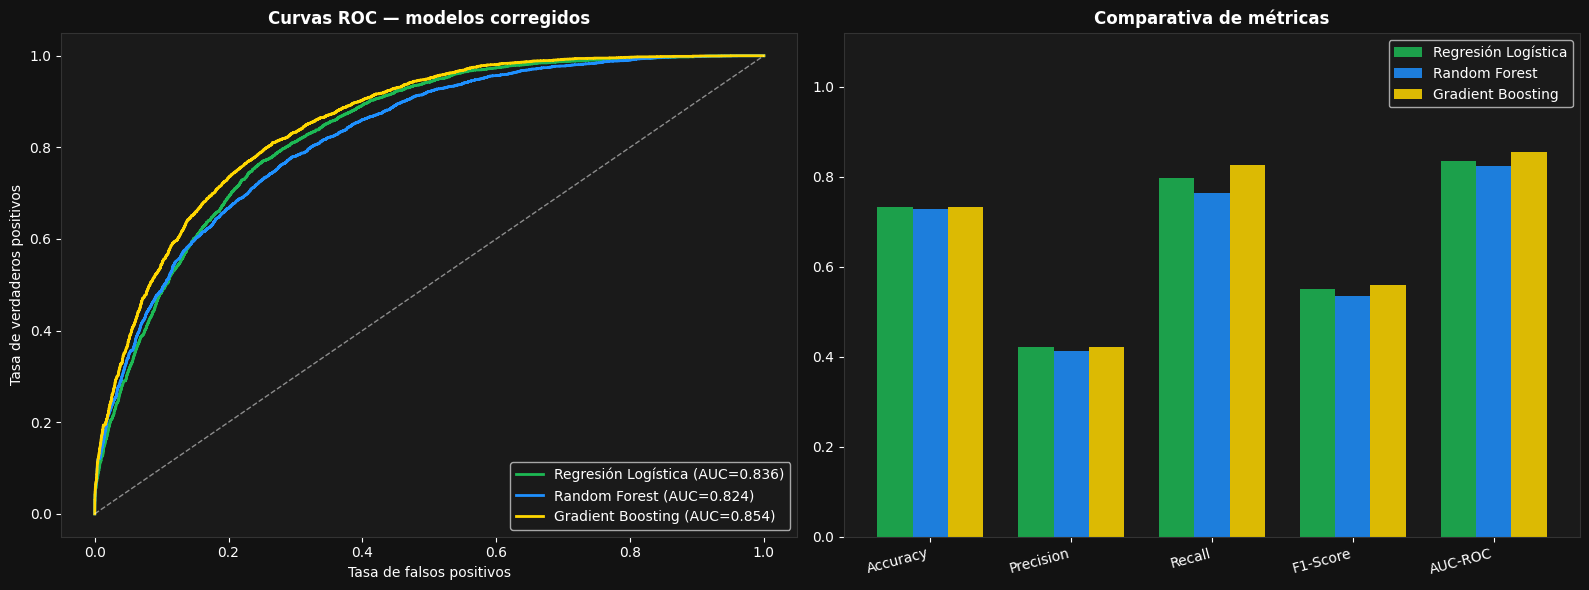

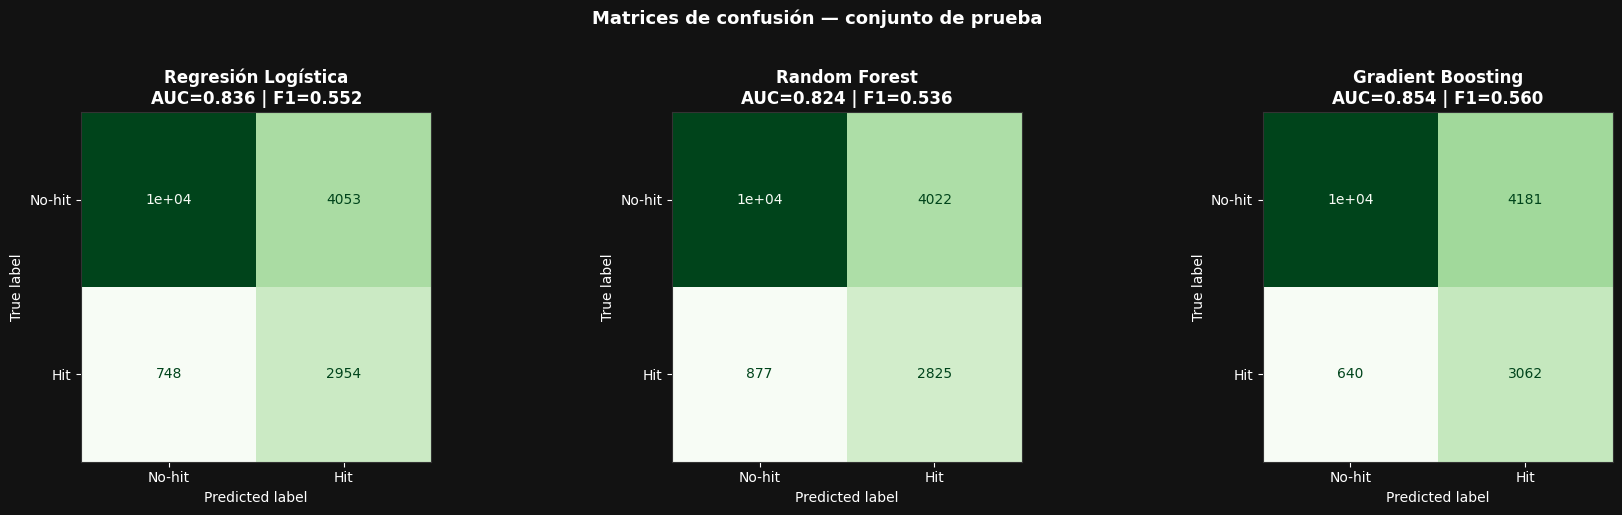

In [11]:
colors = [SPOTIFY_GREEN, '#1E90FF', '#FFD700']
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)

ax1 = axes[0]
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax1.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={r['auc']:.3f})")
ax1.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5)
ax1.set_title('Curvas ROC — modelos corregidos', fontweight='bold')
ax1.set_xlabel('Tasa de falsos positivos'); ax1.set_ylabel('Tasa de verdaderos positivos')
ax1.legend(facecolor='#1a1a1a', labelcolor=TEXT_COLOR)

ax2 = axes[1]
metrics_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc']
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_plot)); w = 0.25
for i, (name, r) in enumerate(results.items()):
    ax2.bar(x + i*w, [r[m] for m in metrics_plot], w, label=name, color=colors[i], alpha=0.85)
ax2.set_xticks(x + w); ax2.set_xticklabels(labels, rotation=15, ha='right')
ax2.set_ylim(0, 1.12); ax2.set_title('Comparativa de métricas', fontweight='bold')
ax2.legend(facecolor='#1a1a1a', labelcolor=TEXT_COLOR)
plt.tight_layout()
plt.savefig('images/comparativa_modelos_roc_corregido.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG_COLOR)
for ax, (name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, r['y_pred']),
                           display_labels=['No-hit', 'Hit']).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f"{name}\nAUC={r['auc']:.3f} | F1={r['f1']:.3f}", fontweight='bold')
plt.suptitle('Matrices de confusión — conjunto de prueba', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/matrices_confusion_corregido.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.1 KPIs de negocio

Además de las métricas estándar, se miden los KPIs definidos en la sección 0: qué tan bien el modelo **prioriza** canciones.
Si el sello solo puede revisar el 10% de las canciones con mayor probabilidad, ¿cuántos hits encuentra en comparación con elegir al azar?

Tasa base de hits en test (elegir al azar): 0.2053


,AUC-ROC,Recall (hit),Precision (umbral 0.5),Lift (umbral 0.5),Precision top-10%,Lift @ top-10%,% hits capturados top-10%,% hits capturados top-20%
Regresión Logística,0.8357,0.7979,0.4216,2.0537,0.6184,3.0126,0.3012,0.5254
Random Forest,0.8241,0.7631,0.4126,2.0099,0.6484,3.1585,0.3158,0.5292
Gradient Boosting,0.8544,0.8271,0.4228,2.0594,0.6772,3.2989,0.3298,0.5621



=== Cumplimiento de metas de referencia ===
Regresión Logística    AUC-ROC: cumple | Recall (hit): cumple | Lift @ top-10%: cumple
Random Forest          AUC-ROC: cumple | Recall (hit): cumple | Lift @ top-10%: cumple
Gradient Boosting      AUC-ROC: cumple | Recall (hit): cumple | Lift @ top-10%: cumple


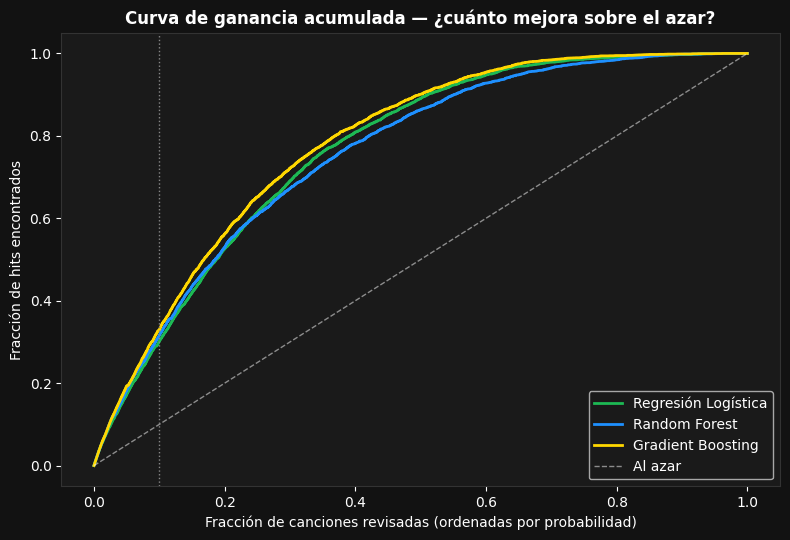

In [12]:
KPI_META = {'AUC-ROC': 0.80, 'Recall (hit)': 0.75, 'Lift @ top-10%': 2.0}
base_rate = y_test.mean()
y_arr = y_test.values

kpi_rows = {}
for name, r in results.items():
    order = np.argsort(-r['y_proba'])
    def top_frac(frac):
        n = int(len(order) * frac)
        sel = y_arr[order[:n]]
        return sel.mean(), sel.sum() / y_arr.sum()
    p10, c10 = top_frac(0.10)
    p20, c20 = top_frac(0.20)
    kpi_rows[name] = {
        'AUC-ROC': r['auc'], 'Recall (hit)': r['recall'],
        'Precision (umbral 0.5)': r['precision'], 'Lift (umbral 0.5)': r['precision'] / base_rate,
        'Precision top-10%': p10, 'Lift @ top-10%': p10 / base_rate,
        '% hits capturados top-10%': c10, '% hits capturados top-20%': c20,
    }
kpi_df = pd.DataFrame(kpi_rows).T.round(4)
print(f'Tasa base de hits en test (elegir al azar): {base_rate:.4f}')
display(kpi_df)

print('\n=== Cumplimiento de metas de referencia ===')
for name in kpi_df.index:
    chk = {k: ('cumple' if kpi_df.loc[name, k] >= meta else 'NO cumple') for k, meta in KPI_META.items()}
    print(f'{name:<22}', ' | '.join(f'{k}: {v}' for k, v in chk.items()))

# Curva de ganancia acumulada: % de hits encontrados al revisar el X% mejor rankeado
fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=BG_COLOR)
for (name, r), color in zip(results.items(), [SPOTIFY_GREEN, '#1E90FF', '#FFD700']):
    order = np.argsort(-r['y_proba'])
    gain = np.cumsum(y_arr[order]) / y_arr.sum()
    frac = np.arange(1, len(order) + 1) / len(order)
    ax.plot(frac, gain, color=color, lw=2, label=name)
ax.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5, label='Al azar')
ax.axvline(0.10, color='#888888', ls=':', lw=1)
ax.set_xlabel('Fracción de canciones revisadas (ordenadas por probabilidad)')
ax.set_ylabel('Fracción de hits encontrados')
ax.set_title('Curva de ganancia acumulada — ¿cuánto mejora sobre el azar?', fontweight='bold')
ax.legend(facecolor='#1a1a1a', labelcolor=TEXT_COLOR)
plt.tight_layout()
plt.savefig('images/curva_ganancia_acumulada.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.2 Diagnóstico: ¿el modelo da más puntaje a las canciones con más géneros?

La observación del docente en EP1 fue que una canción con más categorías (géneros) se volvía más relevante para el modelo.
Hay **dos mecanismos distintos** que podrían producirlo, y se revisan por separado:

1. **Peso en el entrenamiento:** en EP1 una canción en 4 géneros aparecía en 4 filas. Se corrige con **una fila por canción** (sección 3).
2. **Puntaje del modelo:** aunque cada canción pese una vez, el modelo podría dar mayor probabilidad a las canciones con más géneros. Se mide a continuación.

Para saber si el modelo **usa el conteo de géneros**, se prueban tres representaciones del género y se observa si la relación desaparece:
- **A) Multi-hot** (la del modelo principal): 0/1 por género; el número de géneros es visible (suma de la fila).
- **B) Proporciones:** cada fila de géneros se divide por su suma (una canción de 2 géneros vale 0.5 + 0.5).
- **C) Un solo género por canción** (el primero en orden alfabético, una regla arbitraria sin usar la popularidad): el modelo **no puede** conocer cuántos géneros tiene la canción.

In [13]:
# (1) Cada canción pesa una sola vez en el entrenamiento
assert df_song.index.is_unique and train.index.is_unique
print(f'Canciones en train: {len(train):,} | filas repetidas por track_id: {train.index.duplicated().sum()}  -> cada canción pesa 1')

# (2) Puntaje del modelo principal según el número de géneros de la canción
test_diag = test.copy()
test_diag['n_generos'] = test_diag[FEATURES_GENRE].sum(axis=1)
test_diag['proba'] = results['Gradient Boosting']['y_proba']
test_diag['grupo'] = test_diag['n_generos'].clip(upper=3).map({1: '1 género', 2: '2 géneros', 3: '3 o más'})
diag = test_diag.groupby('grupo').agg(canciones=('hit', 'size'), hit_rate_real=('hit', 'mean'),
                                      popularity_media=('popularity', 'mean'), proba_media=('proba', 'mean')).round(3)
display(diag)
print('Correlación n° de géneros vs probabilidad del modelo:', round(test_diag['n_generos'].corr(test_diag['proba']), 3))
print('Correlación n° de géneros vs popularity real         :', round(test_diag['n_generos'].corr(test_diag['popularity']), 3))

Canciones en train: 71,706 | filas repetidas por track_id: 0  -> cada canción pesa 1


,canciones,hit_rate_real,popularity_media,proba_media
grupo,,,,
1 género,14678,0.178,32.108,0.381
2 géneros,2286,0.346,39.683,0.517
3 o más,1070,0.279,28.314,0.543


Correlación n° de géneros vs probabilidad del modelo: 0.205
Correlación n° de géneros vs popularity real         : -0.004


In [14]:
# (3) ¿Desaparece la relación si el modelo no puede contar géneros?
primer_genero = generos.loc[df_song.index].apply(lambda g: g[0])
def matriz_genero(variante, d):
    base = d[FEATURES_SCALE + FEATURES_CAT + FEATURES_BIN].copy()
    G = d[FEATURES_GENRE]
    if variante == 'A) Multi-hot (actual)':
        return pd.concat([base, G], axis=1)
    if variante == 'B) Proporciones (suma 1)':
        return pd.concat([base, G.div(G.sum(axis=1), axis=0)], axis=1)
    P = pd.get_dummies(primer_genero.loc[d.index]).astype(int)
    P.columns = ['genre_' + c for c in P.columns]
    P = P.reindex(columns=FEATURES_GENRE, fill_value=0)
    return pd.concat([base, P], axis=1)

ng_grupo = test['n_generos'].clip(upper=3) if 'n_generos' in test else test[FEATURES_GENRE].sum(axis=1).clip(upper=3)
n_gen_test = test[FEATURES_GENRE].sum(axis=1)
y_arr = y_test.values
filas = []
for variante in ['A) Multi-hot (actual)', 'B) Proporciones (suma 1)', 'C) Un solo género']:
    Xa, Xb = matriz_genero(variante, train), matriz_genero(variante, test)
    for nombre, clf in [
        ('Regresión Logística', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)),
        ('Gradient Boosting', HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=6,
                                                             class_weight='balanced', random_state=SEED))]:
        pipe = Pipeline([('pre', make_pre()), ('clf', clf)]).fit(Xa, y_train)
        p = pipe.predict_proba(Xb)[:, 1]
        pred = (p >= 0.5).astype(int)
        top = y_arr[np.argsort(-p)[:int(len(p) * 0.10)]].mean()
        por_grupo = pd.Series(p).groupby(ng_grupo.values).mean()
        filas.append({'Representación del género': variante, 'Modelo': nombre,
                      'AUC': roc_auc_score(y_arr, p), 'F1': f1_score(y_arr, pred), 'Recall': recall_score(y_arr, pred),
                      'Lift @ top-10%': top / y_arr.mean(),
                      'Corr(n° géneros, proba)': np.corrcoef(n_gen_test, p)[0, 1],
                      'Proba media 1 género': por_grupo.get(1), 'Proba media 2': por_grupo.get(2), 'Proba media 3+': por_grupo.get(3)})
variantes_df = pd.DataFrame(filas).set_index(['Representación del género', 'Modelo']).round(4)
display(variantes_df)

AUC      F1  Recall  \
Representación del género Modelo                                        
A) Multi-hot (actual)     Regresión Logística  0.8357  0.5517  0.7979   
                          Gradient Boosting    0.8544  0.5595  0.8271   
B) Proporciones (suma 1)  Regresión Logística  0.8376  0.5456  0.7990   
                          Gradient Boosting    0.8594  0.5631  0.8390   
C) Un solo género         Regresión Logística  0.8324  0.5433  0.7996   
                          Gradient Boosting    0.8437  0.5355  0.8339   

                                               Lift @ top-10%  \
Representación del género Modelo                                
A) Multi-hot (actual)     Regresión Logística          3.0126   
                          Gradient Boosting            3.2989   
B) Proporciones (suma 1)  Regresión Logística          3.1260   
                          Gradient Boosting            3.3503   
C) Un solo género         Regresión Logística          3.1071   
                          Gradient Boosting            3.2341   

                                               Corr(n° géneros, proba)  \
Representación del género Modelo                                         
A) Multi-hot (actual)     Regresión Logística                   0.2087   
                          Gradient Boosting                     0.2049   
B) Proporciones (suma 1)  Regresión Logística                   0.2154   
                          Gradient Boosting                     0.2174   
C) Un solo género         Regresión Logística                   0.2364   
                          Gradient Boosting                     0.2193   

                                               Proba media 1 género  \
Representación del género Modelo                                      
A) Multi-hot (actual)     Regresión Logística                0.3676   
                          Gradient Boosting                  0.3810   
B) Proporciones (suma 1)  Regresión Logística                0.3641   
                          Gradient Boosting                  0.3783   
C) Un solo género         Regresión Logística                0.3659   
                          Gradient Boosting                  0.3873   

                                               Proba media 2  Proba media 3+  
Representación del género Modelo                                              
A) Multi-hot (actual)     Regresión Logística         0.5100          0.5701  
                          Gradient Boosting           0.5173          0.5431  
B) Proporciones (suma 1)  Regresión Logística         0.5185          0.5782  
                          Gradient Boosting           0.5394          0.5388  
C) Un solo género         Regresión Logística         0.5366          0.5915  
                          Gradient Boosting           0.5233          0.5518

**Resultados (ejecución con `SEED = 42`):**

- **Peso en el entrenamiento: corregido.** Hay 0 filas repetidas por `track_id`; cada canción pesa una vez.
- **El puntaje sí sube con el número de géneros.** La probabilidad media del modelo principal es 0.381 con 1 género, 0.517 con 2 y 0.543 con 3 o más (correlación 0.205). La tasa real de hits es 17.8%, 34.6% y 27.9%.
- **Pero el modelo no lo consigue "contando categorías".** Con un solo género por canción (variante C) el modelo no puede conocer cuántos géneros tiene y la relación **sigue igual**: correlación 0.219 (Gradient Boosting) y 0.236 (Regresión Logística). Con proporciones (variante B) también persiste (0.217 y 0.215). Neutralizar el conteo no elimina la relación.
- **Lo que explica la relación es que son canciones distintas.** En este dataset las canciones con 2 géneros tienen casi el doble de tasa de hits que las de 1 género (34.6% vs 17.8%), y eso se refleja en su audio y en su género principal. Es una asociación presente en los datos, no un artefacto del entrenamiento. La correlación entre el número de géneros y la popularidad promedio es prácticamente nula (−0.004), porque las canciones con 3 o más géneros tienen una popularidad media menor (28.3); la diferencia aparece solo en la proporción que supera el umbral de hit.
- **Un punto a vigilar:** el grupo de 3 o más géneros (1.070 canciones en test) recibe la probabilidad más alta (0.543) aunque su tasa real (27.9%) es menor que la de 2 géneros (34.6%). Es una sobreestimación moderada en un grupo pequeño.
- **Hipótesis no evaluada:** que las canciones presentes en más listas sean más populares, o que el muestreo del dataset (~1.000 canciones por género) favorezca a las canciones multi-género populares.

**Decisión:** se mantiene la representación multi-hot (A) como modelo principal. Las variantes B y C no eliminan la relación, y sus diferencias de AUC (entre −0.011 y +0.005) son pequeñas frente a la desviación de la validación cruzada (0.003 a 0.005); C además pierde información de género. La corrección que responde a la observación del docente es **una fila por canción**.

### 7.3 ¿Cuánto aporta realmente el audio frente al género? (ablación)

**Motivación.** En la sección 8 el género concentra el 73.4% de la importancia del Random Forest y la regresión logística casi iguala a Gradient Boosting. Pero la importancia de variables no dice cuánto rinde el modelo *sin* esas variables. La forma directa de medirlo es una **ablación**: mismo split por canción, mismo `Pipeline`, mismos hiperparámetros y mismo umbral P80 (52 pts, calculado solo con train); solo cambia el conjunto de columnas.

| Variante | Columnas | Qué responde |
|---|---|---|
| A) Todo | audio + metadatos + género (modelo principal) | Rendimiento de referencia |
| B) Solo audio | sin columnas `genre_*` | ¿Qué tan bien se predice por las cualidades de la canción, sin saber su género? |
| C) Solo género | solo columnas `genre_*` | ¿Cuánto se explica sabiendo únicamente el género? |

Se usan Regresión Logística y HistGradientBoosting: el baseline interpretable y el mejor modelo.

In [15]:
# 7.3 Ablación: aporte real del audio vs género
FEATS_AUDIO = FEATURES_SCALE + FEATURES_CAT + FEATURES_BIN

def build(kind, feats):
    tr = []
    sc = [c for c in feats if c in FEATURES_SCALE]
    ct = [c for c in feats if c in FEATURES_CAT]
    if sc: tr.append(('num', StandardScaler(), sc))
    if ct: tr.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ct))
    pre = ColumnTransformer(tr, remainder='passthrough') if tr else 'passthrough'
    clf = (LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
           if kind == 'LR' else
           HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=6,
                                          class_weight='balanced', random_state=SEED))
    return Pipeline([('pre', pre), ('clf', clf)])

def evalua(kind, feats, Xtr, ytr, Xte, yte):
    m = build(kind, feats).fit(Xtr[feats], ytr)
    p = m.predict_proba(Xte[feats])[:, 1]
    yh = (p >= 0.5).astype(int)
    top = yte.values[np.argsort(-p)[:int(len(p) * 0.10)]].mean()
    return {'AUC': roc_auc_score(yte, p), 'F1': f1_score(yte, yh),
            'Recall': recall_score(yte, yh), 'Lift @ top-10%': top / yte.mean()}

variantes_abl = {'A) Todo': ALL_FEATURES,
                 'B) Solo audio (sin género)': FEATS_AUDIO,
                 'C) Solo género': FEATURES_GENRE}
rows = {}
for kind in ['LR', 'HistGB']:
    for v, f in variantes_abl.items():
        rows[(kind, v)] = evalua(kind, f, X_train, y_train, X_test, y_test)
abl_df = pd.DataFrame(rows).T.round(4)
display(abl_df)
for kind in ['LR', 'HistGB']:
    a = abl_df.loc[(kind, 'A) Todo'), 'AUC']
    b = abl_df.loc[(kind, 'B) Solo audio (sin género)'), 'AUC']
    c = abl_df.loc[(kind, 'C) Solo género'), 'AUC']
    print(f'{kind}: caída de AUC al quitar el género = {a-b:.4f} | aporte del audio sobre el género = {a-c:+.4f}')

AUC      F1  Recall  Lift @ top-10%
LR     A) Todo                     0.8357  0.5517  0.7979          3.0126
       B) Solo audio (sin género)  0.6324  0.3725  0.6175          1.6211
       C) Solo género              0.8314  0.5433  0.7861          2.9963
HistGB A) Todo                     0.8544  0.5595  0.8271          3.2989
       B) Solo audio (sin género)  0.6952  0.4192  0.6831          2.0507
       C) Solo género              0.8393  0.5648  0.7326          3.1990

LR: caída de AUC al quitar el género = 0.2033 | aporte del audio sobre el género = +0.0043
HistGB: caída de AUC al quitar el género = 0.1592 | aporte del audio sobre el género = +0.0151


**Resultados (ejecución con `SEED = 42`):**

| Modelo | Variante | AUC | Lift @ top-10% |
|---|---|---|---|
| Regresión Logística | A) Todo | 0.8357 | 3.01 |
| Regresión Logística | B) Solo audio | 0.6324 | 1.62 |
| Regresión Logística | C) Solo género | 0.8314 | 3.00 |
| HistGradientBoosting | A) Todo | 0.8544 | 3.30 |
| HistGradientBoosting | B) Solo audio | 0.6952 | 2.05 |
| HistGradientBoosting | C) Solo género | 0.8393 | 3.20 |

- **Sin género, el AUC cae 0.20 (LR) y 0.16 (HistGB).** Es una caída enorme frente a la desviación de la validación cruzada (0.003 a 0.005), así que no es ruido.
- **Saber solo el género casi iguala al modelo completo:** 0.8393 contra 0.8544 en HistGB y 0.8314 contra 0.8357 en LR. Agregar el audio suma apenas +0.015 y +0.004 de AUC.
- **El audio sí tiene señal, pero modesta:** AUC 0.63–0.70, por encima del azar (0.50) y por debajo de la meta de 0.80. Sin género, solo HistGB queda en el límite del KPI de lift (2.05 contra meta ≥ 2.0), y ningún modelo cumple la meta de AUC.
- **Matiz importante:** B **subestima** el aporte total del audio, porque el audio también informa indirectamente el género (por eso K-Means recupera familias de género a partir de audio). La ablación mide cuánto se pierde al *quitar* la columna de género, no cuánto "vale" el audio en términos causales. Tampoco prueba que el género *cause* la popularidad: puede reflejar exposición algorítmica (sesgo visto en EP1).

**Conclusión para la defensa:** el modelo predice sobre todo *a qué género pertenece la canción* y qué tan popular es ese género hoy en Spotify; las cualidades de audio aportan una señal real pero secundaria. Esto es un **hallazgo a reportar**, no un error a corregir, y se traduce en la recomendación de negocio 3 (sección 12.2).

### 7.4 Experimento secundario: umbral de hit relativo al género

**Motivación.** Si el problema fuera que "el reggaeton siempre gana", una canción sería *hit* solo si supera el P80 **dentro de su género**; así el modelo no podría ganar solo por conocer el género.

**Decisiones y límites (se declaran porque afectan cómo leer el resultado):**
- Una canción puede tener varios géneros y entonces no tiene un percentil único. Se usa su **primer género** (`primer_genero`, el primero en orden alfabético): es una convención, no el "género principal" real.
- El P80 por género se calcula **solo con train**; se usa `clip(lower=1)` para evitar que un género con P80 = 0 convierta a todas sus canciones en hit (en los datos ningún género lo necesitó).
- **El target cambia de significado** (ya no es "popular en Spotify" sino "popular para su género"), así que sus métricas **no son comparables** con los KPIs de la sección 7.1. Por eso es un experimento secundario y **no reemplaza** el target principal.

In [16]:
# 7.4 Target relativo al género (experimento secundario; NO reemplaza al target principal)
g_tr = primer_genero.loc[train.index]
g_te = primer_genero.loc[test.index]
p80g_raw = train.groupby(g_tr)['popularity'].quantile(0.80)
print(f'Géneros con P80 <= 1 (requieren clip): {(p80g_raw <= 1).sum()}')
p80g = p80g_raw.clip(lower=1)
y_tr_rel = pd.Series((train['popularity'].values >= g_tr.map(p80g).fillna(P80).values).astype(int), index=train.index)
y_te_rel = pd.Series((test['popularity'].values  >= g_te.map(p80g).fillna(P80).values).astype(int), index=test.index)
print(f'Tasa de hits relativa -> train {y_tr_rel.mean():.3f} | test {y_te_rel.mean():.3f}')

rows = {}
for v, f in [('Todo', ALL_FEATURES), ('Solo audio', FEATS_AUDIO)]:
    rows[('HistGB', v)] = evalua('HistGB', f, X_train, y_tr_rel, X_test, y_te_rel)
rel_df = pd.DataFrame(rows).T.round(4)
display(rel_df)

Géneros con P80 <= 1 (requieren clip): 0
Tasa de hits relativa -> train 0.217 | test 0.216


AUC      F1  Recall  Lift @ top-10%
HistGB Todo        0.6491  0.3903  0.5814          1.9640
       Solo audio  0.5730  0.3509  0.5752          1.4146

**Resultados:** la tasa de hits queda en 21.7% (train) y 21.6% (test). HistGradientBoosting baja a **AUC 0.6491** con todas las variables y a **0.5730** solo con audio.

- **Dentro de un mismo género, el audio casi no distingue hits de no-hits** (0.573, apenas sobre el azar). Esto refuerza lo visto en 7.3: la señal "útil" del modelo principal viene en gran parte de saber qué género es popular.
- El género sigue aportando algo (0.649 contra 0.573). Hipótesis no evaluada: como el target solo usa el primer género, las columnas de los demás géneros de una canción multi-género siguen llevando información.
- **Decisión:** se mantiene el target global (P80 de train) como modelo principal, porque responde la pregunta de negocio original ("¿es una canción popular en Spotify?") y permite comparar con los KPIs. El target relativo queda como **diagnóstico complementario**.

### 7.5 Alternativa de codificación: Target Encoding regularizado

**Motivación.** Reemplazar las 114 columnas multi-hot por **una sola columna numérica** (tasa de hits media del género) con regularización para géneros con pocas canciones, para comprobar si el resultado depende de cómo se codifica el género.

**Cómo se hizo sin fuga de datos (el riesgo principal de esta técnica, porque usa el target):**
- La tasa por género se calcula con **suavizado**: `(hits_g + m·tasa_global) / (n_g + m)` con `m = 20`; los géneros con pocas canciones se acercan a la tasa global.
- En train se usa una estimación **out-of-fold** (`StratifiedGroupKFold` de 5 folds por canción): la canción nunca ve su propio target.
- En test se usa la tasa calculada con todo train.
- Una canción multi-género recibe el **promedio** de los valores de sus géneros.

In [17]:
# 7.5 Target Encoding regularizado (OOF dentro de train, sin fuga)
G_tr, G_te = train[FEATURES_GENRE], test[FEATURES_GENRE]

def te_fit(G, y, m=20):              # m = peso del prior global (regularización)
    n, h, gm = G.sum(0), G.T.dot(y), y.mean()
    return (h + m * gm) / (n + m)

def te_apply(G, enc):                # canción multi-género: promedio de sus géneros
    return (G.values @ enc.values) / np.maximum(G.sum(1).values, 1)

oof = np.zeros(len(train))
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
for a, b in skf.split(X_train, y_train, groups=g_train):
    oof[b] = te_apply(G_tr.iloc[b], te_fit(G_tr.iloc[a], y_train.iloc[a]))
enc_full = te_fit(G_tr, y_train)

Xtr_te = X_train[FEATS_AUDIO].copy(); Xtr_te['genre_te'] = oof
Xte_te = X_test[FEATS_AUDIO].copy();  Xte_te['genre_te'] = te_apply(G_te, enc_full)
feats_te = FEATS_AUDIO + ['genre_te']

te_df = pd.DataFrame({('HistGB', 'Audio + TE'): evalua('HistGB', feats_te, Xtr_te, y_train, Xte_te, y_test),
                      ('LR',     'Audio + TE'): evalua('LR',     feats_te, Xtr_te, y_train, Xte_te, y_test)}).T.round(4)
display(te_df)

,,AUC,F1,Recall,Lift @ top-10%
HistGB,Audio + TE,0.8482,0.5633,0.7985,3.1774
LR,Audio + TE,0.8335,0.5554,0.7458,3.1017


**Resultados:** con Target Encoding, HistGradientBoosting obtiene **AUC 0.8482** (lift 3.18) y la Regresión Logística **0.8335** (lift 3.10), contra 0.8544 y 0.8357 con multi-hot.

- **El rendimiento es prácticamente el mismo** con 1 columna que con 114: el hallazgo de 7.3 no depende de la codificación del género.
- Tampoco "evita que el modelo aprenda el diccionario de géneros": esa única columna *es* el diccionario (géneros → popularidad media), solo que comprimido.
- **Decisión:** se mantiene el multi-hot como modelo principal. No mejora el AUC, conserva el efecto específico de cada género y no depende del target para construir features (menos riesgo de fuga). El Target Encoding queda como **prueba de robustez**.

### 7.6 Síntesis de 7.2 a 7.5

| Pregunta | Prueba | Resultado | Decisión |
|---|---|---|---|
| ¿Pesan más las canciones con más géneros en el entrenamiento? | Una fila por canción (sección 3) | Corregido: 0 filas repetidas | Se mantiene |
| ¿El modelo "cuenta" géneros? | 7.2: proporciones y un solo género | La relación persiste; no es conteo | Se mantiene multi-hot |
| ¿Cuánto aporta el audio sin género? | 7.3: ablación | AUC cae 0.16–0.20; el género explica casi todo | Se reporta como hallazgo |
| ¿Se corrige con un umbral por género? | 7.4: target relativo | Cambia el problema; el audio casi no discrimina | Solo diagnóstico |
| ¿Se corrige con Target Encoding? | 7.5: TE out-of-fold | Mismo rendimiento (−0.006 y −0.002 de AUC) | Solo robustez |

## 8. Importancia de variables (Random Forest)

Las columnas one-hot y multi-hot se suman por variable original para poder interpretarlas.

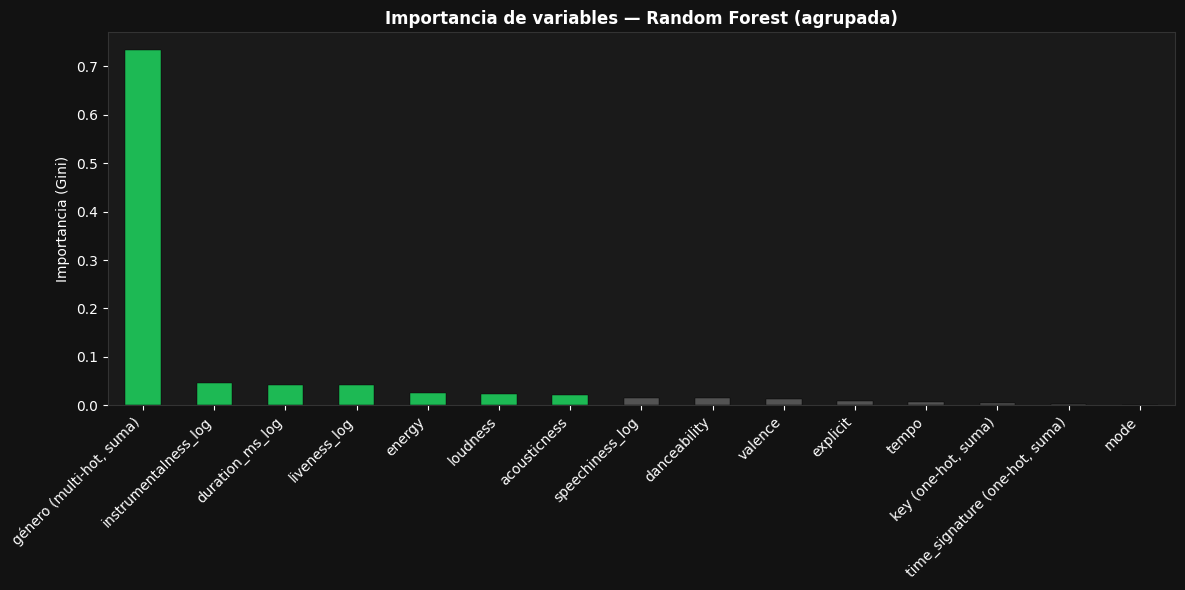

Top 5 variables (agrupadas):
género (multi-hot, suma)    0.7337
instrumentalness_log        0.0451
duration_ms_log             0.0421
liveness_log                0.0420
energy                      0.0262


In [18]:
rf_pipe = results['Random Forest']['model']
names = rf_pipe.named_steps['pre'].get_feature_names_out()
imp = pd.Series(rf_pipe.named_steps['clf'].feature_importances_, index=names)

def agrupar(n):
    if n.startswith('remainder__genre_'):     return 'género (multi-hot, suma)'
    if n.startswith('cat__key_'):             return 'key (one-hot, suma)'
    if n.startswith('cat__time_signature_'):  return 'time_signature (one-hot, suma)'
    return n.split('__', 1)[1]

imp_g = imp.groupby(agrupar).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_COLOR)
cols = [SPOTIFY_GREEN if v > imp_g.median() else '#535353' for v in imp_g]
imp_g.plot(kind='bar', ax=ax, color=cols, edgecolor='black', linewidth=0.3)
ax.set_title('Importancia de variables — Random Forest (agrupada)', fontweight='bold')
ax.set_ylabel('Importancia (Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/feature_importance_rf_corregido.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Top 5 variables (agrupadas):')
print(imp_g.head(5).round(4).to_string())

## 9. Aprendizaje no supervisado: segmentación de canciones por perfil sonoro (K-Means)

**Objetivo de negocio:** descubrir qué *tipos* de canciones existen en el catálogo según cómo suenan, y ver si algunos segmentos concentran más o menos *hits*.
Esto apoya decisiones de catálogo y de estrategia por segmento, distintas de la decisión canción por canción del modelo supervisado.

**Decisiones de diseño:**
- **Técnica:** K-Means. Las variables son continuas y estandarizadas, es interpretable (cada segmento tiene un centroide que se puede leer) y escala bien a ~72 mil canciones.
- **Variables:** solo las **10 características de audio**. No se incluyen `popularity` ni el género: si se incluyeran, los segmentos saldrían de la variable que luego se quiere evaluar (circular). Se segmenta por **cómo suena** y después se mide la tasa de *hits* de cada segmento.
- **Sin fuga:** el escalador y K-Means se ajustan **solo con train**; las canciones de test se asignan al segmento más cercano (`predict`) para validar fuera de muestra.
- **Elección de K:** método del codo, coeficiente de silueta y estabilidad (índice de Rand ajustado entre semillas).
- **PCA:** solo para visualizar los segmentos en 2 dimensiones, no para clusterizar.

,k,inercia,silhouette
0,2,575926.9260,0.2403
1,3,516914.3437,0.1459
2,4,475747.9437,0.1505
3,5,435004.9020,0.1527
4,6,402425.5749,0.1591
5,7,375967.6231,0.1628
6,8,359350.7208,0.1658
7,9,344280.2546,0.1499
8,10,331873.4780,0.1402


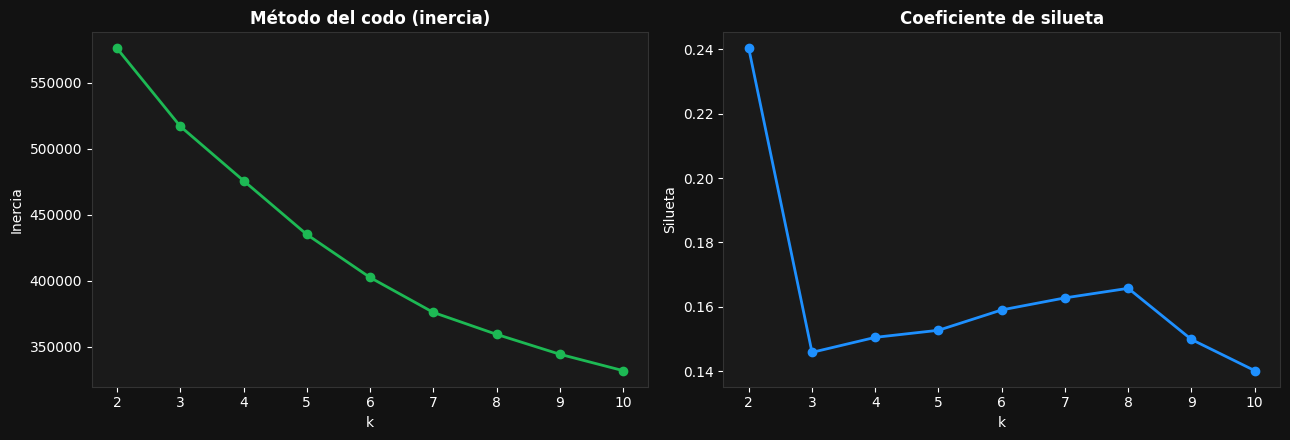

In [19]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

AUDIO_FEATS = FEATURES_SCALE
scaler_seg = StandardScaler().fit(train[AUDIO_FEATS])
Z_train = scaler_seg.transform(train[AUDIO_FEATS])
Z_test  = scaler_seg.transform(test[AUDIO_FEATS])

rng = np.random.RandomState(SEED)
idx_sil = rng.choice(len(Z_train), size=10000, replace=False)   # muestra para la silueta (costo O(n^2))

filas = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Z_train)
    filas.append({'k': k, 'inercia': km.inertia_,
                  'silhouette': silhouette_score(Z_train[idx_sil], km.labels_[idx_sil])})
sel_k = pd.DataFrame(filas)
display(sel_k.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG_COLOR)
axes[0].plot(sel_k['k'], sel_k['inercia'], 'o-', color=SPOTIFY_GREEN, lw=2)
axes[0].set_title('Método del codo (inercia)', fontweight='bold'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(sel_k['k'], sel_k['silhouette'], 'o-', color='#1E90FF', lw=2)
axes[1].set_title('Coeficiente de silueta', fontweight='bold'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silueta')
plt.tight_layout()
plt.savefig('images/kmeans_seleccion_k.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

K = 6 | silueta = 0.1591 | estabilidad ARI entre semillas = 0.9969


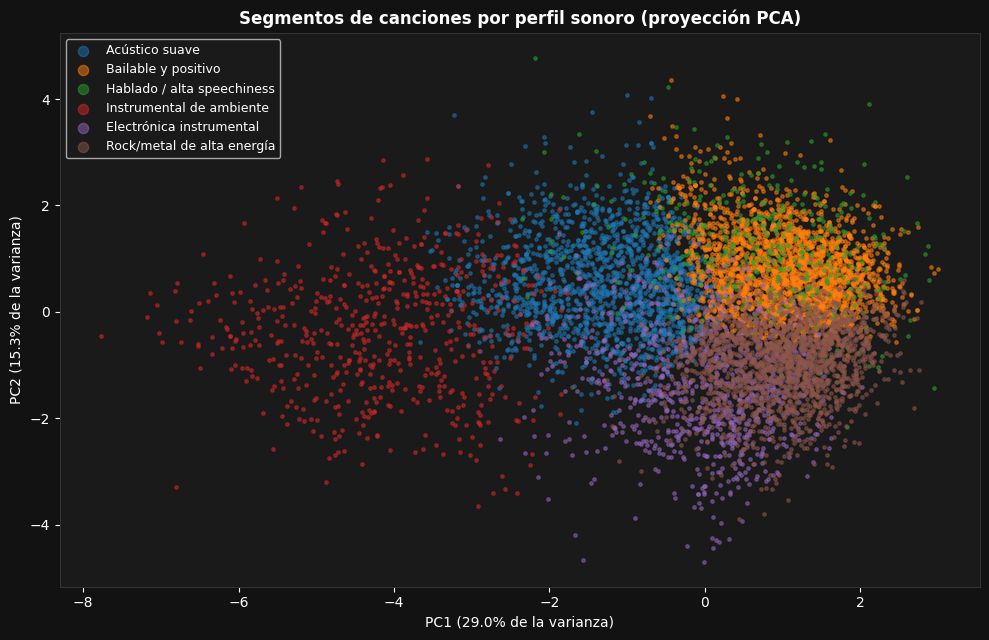

In [20]:
K_FINAL = 6
kmeans = KMeans(n_clusters=K_FINAL, n_init=10, random_state=SEED).fit(Z_train)
seg_train = kmeans.labels_
seg_test  = kmeans.predict(Z_test)

# Estabilidad: mismo K con otra semilla -> ¿se reproducen los mismos segmentos?
ari = adjusted_rand_score(seg_train, KMeans(n_clusters=K_FINAL, n_init=10, random_state=7).fit(Z_train).labels_)
sil_final = silhouette_score(Z_train[idx_sil], seg_train[idx_sil])
print(f'K = {K_FINAL} | silueta = {sil_final:.4f} | estabilidad ARI entre semillas = {ari:.4f}')

# Perfil de cada segmento: centroides en unidades de desviación estándar (z-score)
perfil_z = pd.DataFrame(Z_train, columns=AUDIO_FEATS).groupby(seg_train).mean()

def nombrar_segmento(z):
    if z['speechiness_log'] > 2:                              return 'Hablado / alta speechiness'
    if z['instrumentalness_log'] > 1 and z['acousticness'] > 0.5: return 'Instrumental de ambiente'
    if z['instrumentalness_log'] > 1:                         return 'Electrónica instrumental'
    if z['energy'] < -0.5 and z['acousticness'] > 0.5:        return 'Acústico suave'
    if z['valence'] > 0.5 and z['danceability'] > 0.5:        return 'Bailable y positivo'
    if z['energy'] > 0.5:                                     return 'Rock/metal de alta energía'
    return None

nombres = {}
for c in perfil_z.index:
    n = nombrar_segmento(perfil_z.loc[c])
    nombres[c] = n if (n and n not in nombres.values()) else f'Segmento {c}'

# Visualización 2D con PCA (solo para graficar)
pca = PCA(n_components=2, random_state=SEED).fit(Z_train)
idx_plot = np.random.RandomState(SEED).choice(len(Z_train), size=8000, replace=False)
P = pca.transform(Z_train[idx_plot])
fig, ax = plt.subplots(figsize=(10, 6.5), facecolor=BG_COLOR)
palette = plt.cm.tab10(np.linspace(0, 1, 10))
for i, c in enumerate(perfil_z.index):
    m = seg_train[idx_plot] == c
    ax.scatter(P[m, 0], P[m, 1], s=6, alpha=0.5, color=palette[i], label=nombres[c])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de la varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de la varianza)')
ax.set_title('Segmentos de canciones por perfil sonoro (proyección PCA)', fontweight='bold')
ax.legend(markerscale=3, facecolor='#1a1a1a', labelcolor=TEXT_COLOR, fontsize=9)
plt.tight_layout()
plt.savefig('images/kmeans_segmentos_pca.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

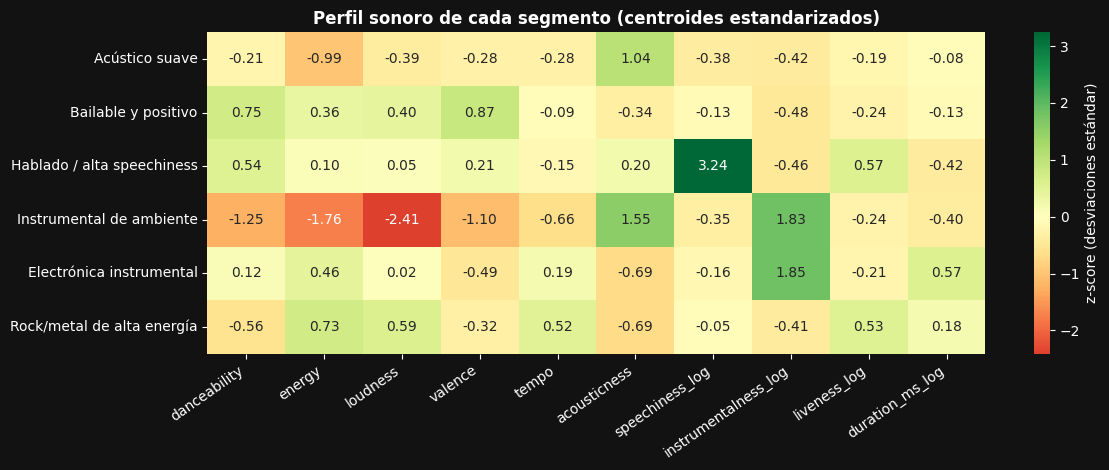

Tasa base de hits — train: 0.210 | test: 0.205


,canciones (train),hit rate train,hit rate test,lift test vs base,popularity media,explicit %,géneros más frecuentes
segmento,,,,,,,
Bailable y positivo,21946,0.246,0.238,1.160,34.827,0.102,"latino, reggaeton, salsa"
Acústico suave,15049,0.224,0.227,1.105,33.627,0.034,"tango, honky-tonk, jazz"
Rock/metal de alta energía,16935,0.221,0.211,1.027,35.529,0.092,"metalcore, heavy-metal, grunge"
Hablado / alta speechiness,3907,0.175,0.178,0.865,32.428,0.388,"comedy, j-dance, dancehall"
Instrumental de ambiente,5482,0.167,0.174,0.848,28.631,0.003,"sleep, new-age, classical"
Electrónica instrumental,8387,0.112,0.102,0.495,27.580,0.036,"minimal-techno, detroit-techno, techno"


In [21]:
# Perfil sonoro (heatmap de centroides) + tasa de hits por segmento (train y test)
fig, ax = plt.subplots(figsize=(12, 4.8), facecolor=BG_COLOR)
sns.heatmap(perfil_z.rename(index=nombres), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax,
            cbar_kws={'label': 'z-score (desviaciones estándar)'})
ax.set_title('Perfil sonoro de cada segmento (centroides estandarizados)', fontweight='bold')
plt.xticks(rotation=35, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('images/kmeans_perfil_segmentos.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

base_train, base_test = train['hit'].mean(), test['hit'].mean()
genre_cols = [c for c in train.columns if c.startswith('genre_')]
genre_share = train[genre_cols].groupby(seg_train).mean()

tabla_seg = pd.DataFrame({
    'segmento': [nombres[c] for c in perfil_z.index],
    'canciones (train)': pd.Series(seg_train).value_counts().sort_index().values,
    'hit rate train': train['hit'].groupby(seg_train).mean().values,
    'hit rate test': test['hit'].groupby(seg_test).mean().reindex(perfil_z.index).values,
    'lift test vs base': (test['hit'].groupby(seg_test).mean().reindex(perfil_z.index) / base_test).values,
    'popularity media': train['popularity'].groupby(seg_train).mean().values,
    'explicit %': train['explicit'].groupby(seg_train).mean().values,
    'géneros más frecuentes': [', '.join(g.replace('genre_', '') for g in
                               genre_share.loc[c].sort_values(ascending=False).head(3).index)
                               for c in perfil_z.index],
}).set_index('segmento').round(3)
print(f'Tasa base de hits — train: {base_train:.3f} | test: {base_test:.3f}')
display(tabla_seg.sort_values('hit rate test', ascending=False))

### 9.1 Elección de K = 6 e interpretación de los segmentos

**Elección de K.** El método del codo no muestra un quiebre nítido (la inercia baja de forma gradual). La silueta es máxima con k = 2 (0.240), pero dos grupos no sirven para diseñar estrategia.
Entre k = 3 y k = 8 la silueta sube levemente (0.146 → 0.166); con **k = 6** la silueta es 0.159 y la estabilidad entre semillas es **ARI = 0.997** (los mismos segmentos se reproducen), y aparecen segmentos musicalmente distintos e interpretables.
Pasar a k = 8 solo aporta +0.007 de silueta a cambio de más segmentos. K = 6 es una decisión de compromiso entre interpretabilidad y estabilidad, **no un óptimo estadístico**.
La silueta baja (≈ 0.16) indica que las características de audio forman un continuo: los segmentos describen bien el catálogo, pero sus fronteras no son nítidas.

**Segmentos encontrados** (hit rate medido en canciones de test, asignadas con `predict`; tasa base = 20.5%):

| Segmento | Perfil sonoro (centroide) | Géneros más frecuentes | Hit rate test | Lift vs base |
|---|---|---|---|---|
| Bailable y positivo | `danceability` +0.75 σ, `valence` +0.87 σ | latino, reggaeton, salsa | 23.8% | 1.16x |
| Acústico suave | `energy` −0.99 σ, `acousticness` +1.04 σ | tango, honky-tonk, jazz | 22.7% | 1.11x |
| Rock/metal de alta energía | `energy` +0.73 σ, `loudness` +0.59 σ, `tempo` +0.52 σ | metalcore, heavy-metal, grunge | 21.1% | 1.03x |
| Hablado / alta speechiness | `speechiness_log` +3.24 σ (39% explícitas) | comedy, j-dance, dancehall | 17.8% | 0.87x |
| Instrumental de ambiente | `instrumentalness_log` +1.83 σ, `loudness` −2.41 σ, `acousticness` +1.55 σ | sleep, new-age, classical | 17.4% | 0.85x |
| Electrónica instrumental | `instrumentalness_log` +1.85 σ, `duration_ms_log` +0.57 σ, `acousticness` −0.69 σ | minimal-techno, detroit-techno, techno | 10.2% | 0.50x |

*(Valores de la ejecución con `SEED = 42`; σ = desviaciones estándar respecto del promedio de train.)*

**Interpretación:**
- Los segmentos son **reproducibles y se confirman fuera de muestra**: el orden de la tasa de hits en test es coherente con train (por ejemplo, Electrónica instrumental: 11.2% en train y 10.2% en test).
- Las diferencias existen pero son **moderadas**: van de 10.2% a 23.8%. Solo Electrónica instrumental se aleja claramente de la tasa base (la mitad); el resto queda entre 0.85x y 1.16x. El perfil sonoro por sí solo **no determina** si una canción será hit, lo que coincide con EP1 (el género pesa más que el audio).
- Los segmentos se solapan con familias de géneros (columna de géneros frecuentes): es esperable, porque el género condiciona cómo suena una canción. La segmentación aporta una vista del catálogo por sonido, no una regla de inversión por sí sola.

## 10. Resumen automático de resultados

In [22]:
mejor = max(results, key=lambda n: results[n]['auc'])
print(f"Mejor modelo por AUC-ROC en test (métrica principal): {mejor} (AUC = {results[mejor]['auc']:.4f}, "
      f"F1 = {results[mejor]['f1']:.4f}, recall = {results[mejor]['recall']:.4f})")
print()
for n in results:
    gap_cv = cv_table.loc[n, 'Gap AUC']
    estado = 'sin sobreajuste significativo' if gap_cv < 0.05 else 'SOBREAJUSTE (gap >= 0.05)'
    print(f"{n:<22} gap AUC (CV) = {gap_cv:.4f} -> {estado}")

Mejor modelo por AUC-ROC en test (métrica principal): Gradient Boosting (AUC = 0.8544, F1 = 0.5595, recall = 0.8271)

Regresión Logística    gap AUC (CV) = 0.0030 -> sin sobreajuste significativo
Random Forest          gap AUC (CV) = 0.0214 -> sin sobreajuste significativo
Gradient Boosting      gap AUC (CV) = 0.0287 -> sin sobreajuste significativo


## 11. Serialización y guardado de modelos entrenados (models/)

Se guardan los pipelines completos (preprocesamiento + clasificador) en la carpeta `models/` utilizando `joblib`.
Esto permite cargar cualquier modelo en producción o futuras evaluaciones con un solo comando, recibiendo los datos crudos sin riesgo de data leakage.

In [23]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Mapeo de nombres limpios para serialización
filename_map = {
    'regresi': 'models/logistic_regression.joblib',
    'random forest': 'models/random_forest.joblib',
    'gradient': 'models/gradient_boosting.joblib'
}

print('=== Guardando modelos en carpeta models/ ===')
for name, data in results.items():
    pipe = data['model']
    target_path = None
    for key, path in filename_map.items():
        if key in name.lower():
            target_path = path
            break
    if target_path is None:
        safe_name = ''.join(ch if ch.isalnum() else '_' for ch in name.lower())
        target_path = f'models/{safe_name}.joblib'
    
    joblib.dump(pipe, target_path)
    size_mb = os.path.getsize(target_path) / (1024 * 1024)
    print(f'[OK] {name:<25} -> {target_path} ({size_mb:.2f} MB)')

# Guardar copia explícita del mejor modelo seleccionado
best_path = 'models/best_model.joblib'
if 'mejor' in locals() and mejor in results:
    joblib.dump(results[mejor]['model'], best_path)
    print(f'[OK] Mejor modelo ({mejor}) guardado como {best_path}')

# Verificación de carga y predicción con datos nuevos
loaded_pipe = joblib.load(best_path)
sample_pred = loaded_pipe.predict(X_test.iloc[:3])
print(f'[OK] Verificación de carga exitosa. Predicciones muestra: {sample_pred}')


=== Guardando modelos en carpeta models/ ===
[OK] Regresión Logística       -> models/logistic_regression.joblib (0.01 MB)
[OK] Random Forest             -> models/random_forest.joblib (5.64 MB)


[OK] Gradient Boosting         -> models/gradient_boosting.joblib (1.08 MB)
[OK] Mejor modelo (Gradient Boosting) guardado como models/best_model.joblib
[OK] Verificación de carga exitosa. Predicciones muestra: [1 1 1]


## 12. Conclusiones y recomendaciones de negocio

### 12.1 Respuesta a la pregunta de negocio: ¿invierto o no en esta canción?
**Sí, pero usando el modelo para priorizar candidatas, no para decidir solo.** El mejor modelo es **Gradient Boosting** (AUC-ROC 0.8544, recall 0.8271, F1 0.5595) y cumple las tres metas de referencia de la sección 0 (ver 7.1).

- **Con umbral 0.5:** detecta el **83%** de los hits reales, pero solo el **42%** de las canciones que marca como hit lo son (precision 0.4228), es decir **2.06 veces** la tasa base de 20.5%. Dicho de otro modo, **más de la mitad de las alertas son falsos positivos**: sirve como filtro que reduce la lista, no como autorización automática de inversión.
- **Como ranking:** si el sello revisa solo el **10% mejor puntuado** (1.803 de 18.034 canciones de test), el **67.7%** son hits (lift **3.30x**) y se capturan el **33.0%** de todos los hits. Con el 20% mejor puntuado se capturan el **56.2%**.
- **Regla recomendada:** en lugar de "invertir si el modelo predice hit", **incluir en la lista corta de revisión humana las canciones del 10–20% con mayor probabilidad**. La decisión final de inversión sigue siendo humana.

### 12.2 Recomendaciones para el negocio
1. **Usar la probabilidad, no la etiqueta.** Ordenar el catálogo por probabilidad de hit y fijar el tamaño de la lista según presupuesto. El umbral de clasificación debe definirse con el costo de invertir en un falso positivo frente al costo de perder un hit (hoy es 0.5, sin costos reales).
2. **Expectativas diferenciadas por segmento.** Electrónica instrumental tiene la mitad de la tasa base de hits (10.2% vs 20.5%); Instrumental de ambiente y Hablado quedan por debajo (17–18%); Bailable y positivo es el más alto (23.8%). No conviene exigir el mismo retorno de popularidad masiva a todos los segmentos. Que algunos segmentos tengan menos hits en Spotify **no significa que tengan menos valor** (por ejemplo, música funcional para dormir o concentrarse): es una hipótesis que este análisis no evalúa.
3. **Transparencia sobre sesgos.** El género concentra el **73.4%** de la importancia en Random Forest, y la regresión logística (AUC 0.8357) casi iguala a Gradient Boosting: gran parte de lo que el modelo aprende es **qué géneros son populares hoy en Spotify**, más que cualidades de la canción. Como se vio en EP1 (sesgo de exposición algorítmica, geográfico y de popularidad acumulada), el modelo puede subestimar canciones de géneros con poca penetración en la plataforma. **No debe usarse para descartar automáticamente** canciones de esos géneros. La ablación de la sección 7.3 lo cuantifica: sin las columnas de género el AUC cae de 0.8544 a 0.6952 (Gradient Boosting) y de 0.8357 a 0.6324 (Regresión Logística), mientras que con solo el género se obtiene 0.8393 y 0.8314. El audio aporta señal real pero secundaria (+0.015 de AUC sobre el género), y las pruebas de 7.4 (umbral por género) y 7.5 (Target Encoding) confirman que el resultado no depende de la codificación ni del umbral.
4. **Mantenimiento.** La popularidad cambia en el tiempo: el modelo debe reentrenarse periódicamente y monitorear que su lift se mantenga.

### 12.3 Limitaciones
- `popularity` es una medida puntual que depende de la exposición algorítmica; la definición de *hit* (P80 del train = 52 pts) es una convención, no un umbral de negocio.
- Faltan variables probablemente decisivas: fecha de lanzamiento, popularidad previa del artista e inversión en marketing.
- La separación es aleatoria por canción, **no temporal**: no se prueba la capacidad de predecir canciones futuras.
- Los hiperparámetros no se optimizaron con búsqueda sistemática, y las metas de los KPIs son valores de referencia definidos por el equipo.
- En la segmentación, la silueta baja (≈ 0.16) indica fronteras difusas entre segmentos y hay solapamiento con el género.
- La ablación (7.3) mide cuánto se pierde al quitar el género, pero subestima el aporte total del audio (el audio también informa el género) y no prueba que el género cause la popularidad; el target relativo (7.4) usa el primer género alfabético y no es comparable con los KPIs.
- Una misma canción con distinto `track_id` se agrupa por artista y nombre; en 720 `track_id` la popularidad difería entre géneros y se usó el promedio.

### 12.4 Aprendizajes del proceso (CRISP-DM iterativo)
- **Duplicados por género:** se pasó de una fila por (canción, género) a una fila por canción con género multi-hot; **en el entrenamiento ya no pesan más las canciones con más géneros** (observación del docente). El puntaje del modelo sí es mayor para canciones multi-género, pero el diagnóstico de la sección 7.2 muestra que no depende de que el modelo cuente géneros (persiste con un solo género por canción) y refleja una diferencia real de tasa de hits en los datos (34.6% con 2 géneros vs 17.8% con 1).
- **Fuga de datos:** el split por fila inflaba el AUC en 0.0453 (30.8% de las filas de test tenían su canción en train); ahora el split y la validación cruzada son por canción.
- **Codificación:** el Label Encoding del género generaba un orden falso; con multi-hot y one-hot la regresión logística subió de AUC 0.6257 a 0.8357.
- **Umbral y escalado:** el P80 y el `StandardScaler` se calculan solo con train, dentro del Pipeline.
- **Dominio del género:** se evaluaron tres propuestas (7.3 a 7.5). La ablación mostró que el género explica casi todo el rendimiento (AUC sin género 0.63–0.70); el umbral por género cambió la pregunta de negocio y el Target Encoding no mejoró el AUC, por lo que se mantuvo el modelo multi-hot y el género dominante se reporta como hallazgo y limitación, no como error corregido.
- **Desbalance:** con `class_weight='balanced'` el recall de Gradient Boosting pasó de 0.15 a 0.83.

### 12.5 Próximos pasos
- Búsqueda sistemática de hiperparámetros con `StratifiedGroupKFold` y calibración de probabilidades.
- Definir el umbral de decisión con costos reales del negocio.
- Incorporar variables de artista y fecha de lanzamiento, y validar con una separación temporal.
- Incorporar señales que separen la calidad del audio de la popularidad del género (artista, fecha, oyentes previos), ya que el audio solo alcanza AUC 0.63–0.70.